Analiza Klasyfikacji Chorób Serca - Regresja Logistyczna.

Zbiór danych Heart Disease to zbiór medyczny zawierający 303 rekordy pacjentów opisane za pomocą 14 cech: wiek, płeć, typ bólu w klatce, ciśnienie tętnicze, poziom cholesterolu, wynik EKG, maksymalne tętno, liczba naczyń krwionośnych widocznych w fluoroskopii i wynik testu talowego. Głównym celem analizy jest przewidzenie zmiennej target, która w oryginale określa stopień zaawansowania choroby (0–4), ale w praktyce najczęściej sprowadzana jest do klasyfikacji binarnej: 0 (brak choroby) oraz 1 (obecność choroby).


Na samym początku musimy zaimportować potrzebne nam biblioteki. Dodatkowo ustawiam tło wykresów na stały kolor w celu lepszej czytelności.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

Zbiór oryginalnie zawiera braki oznaczone jako ? oraz zmienną celu przyjmującą wartości od 0 do 4. Owe braki występują w kolumnach ca i thal, zdecydowalem się na usunięcie tych wierszy, ponieważ stanowią one marginalną część zbioru (ok. 2%).

Poniższa funkcja usuwa dane z ubytkami i mapuje zmienną target na postać binarną (0 - zdrowy, 1 - chory) ponieważ chcemy sprawdzić czy ktoś jest poprostu w jakimś stopniu chory. Dodatkowo gdybyśmy zostawili zmienną target z wartościami <0,4> algorytm nie miałby wystarczającej ilości danych aby prawidłowo zakfalifikować dane ponieważ jest niewiele danych z target = 4.
Regresja Logistyczna w tym przypadku poprostu lepiej sobie radzi z danymi w postaci boolowej.

In [ ]:
def load_and_preprocess(url):
    cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
    df = pd.read_csv(url, names=cols, na_values="?")

    df = df.dropna()
    df['target'] = (df['target'] > 0).astype(int)
    return df

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = load_and_preprocess(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Sprawdzamy liczebność klas oraz korelacje między zmiennymi. Ważne jest, aby zobaczyć, czy klasy są zrównoważone, w przypadku w którym mielibyśmy w naszej bazie prawie same zdrowe osoby mimo tego że accurycity algorytmu było by wysokie byłby on bezużyteczny ponieważ nie miałby wystarczającej ilości danych do nauki zależności.
Prawy wykres pokazuje nam zależnność pomiędzy różnymi danymi (czerwony-silnie zależne, niebieskie - nisko zależne od siebie). Pokazuje nam to które dane mają największy wpływ i są najbardziej znaczące w naszym algorytmie (silne kolory czyli mocny niebieski i mocna czerwień to dane najbardziej znaczące)

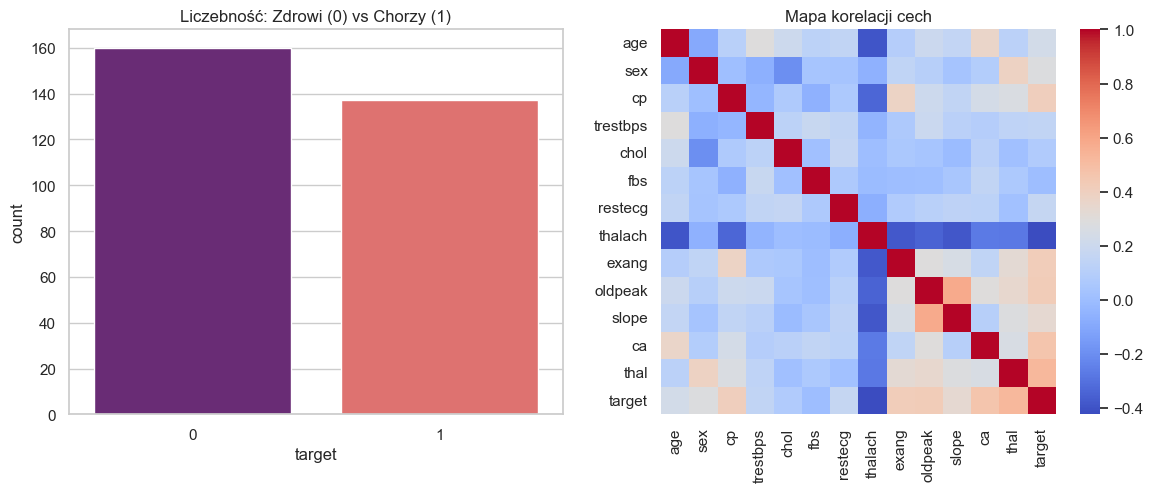

In [11]:
def plot_eda(data):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(x='target', data=data, ax=ax[0], hue='target', palette='magma', legend=False)
    ax[0].set_title("Liczebność: Zdrowi (0) vs Chorzy (1)")

    sns.heatmap(data.corr(), cmap='coolwarm', ax=ax[1])
    ax[1].set_title("Mapa korelacji cech")
    plt.show()


plot_eda(df)

Analiza wag modelu pokazuje, że cechy takie jak ca (liczba naczyń) czy thal mają najsilniejszy dodatni wpływ na ryzyko choroby, podczas gdy thalach (max tętno) ma wpływ ujemny. Pozwala to zrozumieć, dlaczego algorytm podejmuje takie, a nie inne decyzje.

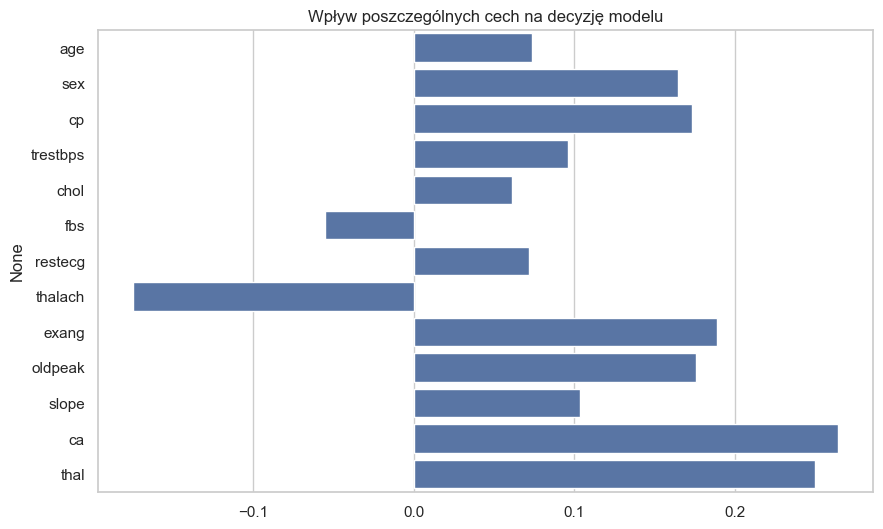

In [24]:
# Pobranie wag modelu
wagi = best_clf.coef_[0]
cechy = X.columns

# Wizualizacja
plt.figure(figsize=(10,6))
sns.barplot(x=wagi, y=cechy)
plt.title("Wpływ poszczególnych cech na decyzję modelu")
plt.show()


Funkcja przygotowuje dane, dzieląc je na część do nauki i egzaminu, wyrównuje ich skalę, a następnie przeprowadza dziesiątki prób z różnymi ustawieniami. Parametr C kontroluje siłę kary za zbyt duże wagi. Mniejsze C oznacza silniejszą regulację, co zapobiega przeuczeniu a solver odpowaida algorytmowi optymalizującemu. Algorytm wybiera i zwraca ten model, który najskuteczniej diagnozuje pacjentów. Gdybyśmy zastosowali inne parametry dla C i solvera, finalny wynik wyglądał by inaczej i mniej dokładniej.

In [44]:
def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    params = {'C': [ 0.01,0.1,1,10], 'solver': ['lbfgs', 'liblinear']}
    grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
    grid.fit(X_train_scaled, y_train)
    
    return grid.best_estimator_, X_test_scaled, y_test, grid.best_params_

X = df.drop('target', axis=1)
y = df['target']
best_clf, X_test_scaled, y_test, best_p = train_model(X, y)

print(f"Najlepsze parametry: {best_p}")

Najlepsze parametry: {'C': 0.01, 'solver': 'lbfgs'}


Sprawdzamy jak algorytm radzi sobie z pacjentami których nie widział podczas nauki. Najpierw model wykonuje dwie operacje: predict (podaje twardy wynik 0 lub 1) oraz predict_proba (podaje procentową pewność np. 85% szans na chorobę). Na te wyniki ogromny wpływ ma skalowanie danych (StandardScaler), bez niego model mógłby ignorować ważne objawy tylko dlatego, że mają niskie wartości liczbowe, co zepsułoby cały algorytm. Następnie funkcja zestawia te przewidywania z prawdziwymi historiami chorób. Dzięki temu generuje statystyki takie jak Czułość, która mówi nam, jaki procent faktycznie chorych osób udało się wykryć. Jest to najważniejszy parametr, na który wpływa dobór parametru C w poprzednim kroku – jeśli C było dobrze dobrane, funkcja pokaże wysoką czułość na nowych pacjentach.

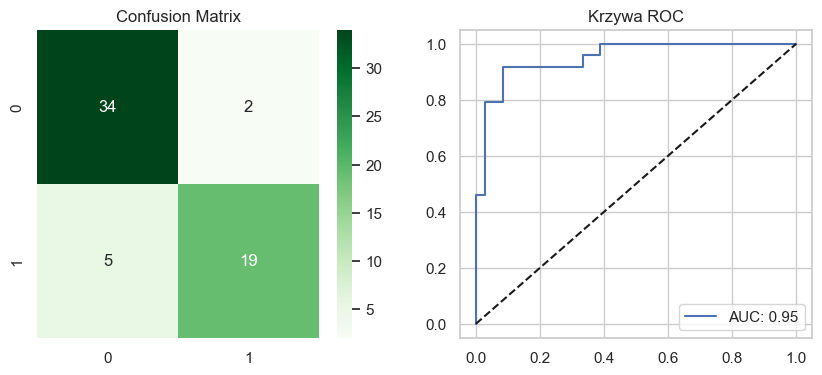

              precision    recall  f1-score   support

           0       0.87      0.94      0.91        36
           1       0.90      0.79      0.84        24

    accuracy                           0.88        60
   macro avg       0.89      0.87      0.88        60
weighted avg       0.88      0.88      0.88        60



In [45]:
def plot_results(model, X_test, y_test):
    y_pred = model.predict(X_test)
    #bierze prawdopodobienstwo
    y_prob = model.predict_proba(X_test)[:, 1]
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Greens')
    plt.title("Confusion Matrix")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'AUC: {auc(fpr, tpr):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Krzywa ROC")
    plt.legend()
    plt.show()
    
    print(classification_report(y_test, y_pred))

plot_results(best_clf, X_test_scaled, y_test)

Wykresy oraz statystyki potwierdzają, że model regresji logistycznej osiągnął bardzo wysoką skuteczność w diagnozowaniu chorób serca. Kluczowym wskaźnikiem jest AUC wynoszące 0,95, co oznacza, że model niemal bezbłędnie potrafi poprawnie rozróżnić osobę chorą od zdrowej. Na Macierzy Pomyłek widzimy, że na 60 przetestowanych pacjentów model trafił aż w 53 przypadkach.

 Wskaźnik Recall (Czułość) na poziomie 0,79 informuje nas, że model zdołał rozpoznać dużą większość chorych osób ze zbioru testowego. Choć 5 osób chorych zostało pominiętych (błędy False Negative), wynik ten w połączeniu z wysokim F1-score świadczy o bardzo dobrym zbalansowaniu modelu.
Niebieska linia na wykresie krzywej ROC pokazuje zależność między wykrywaniem chorych a unikaniem fałszywych alarmów. Im bardziej linia ta "ucieka" w lewy górny róg, tym algorytm diagnozuje poprawniej.

Jeżeli zastosowalibyśmy inne C i inny solver wynik byłby inny. W tym przypadku zastosowując C = 10 widzimy że algorytm wyłapał mniej poprawnych danych ale mniej wyników zinterpretował jako zdrowy mimo bycia chorym.

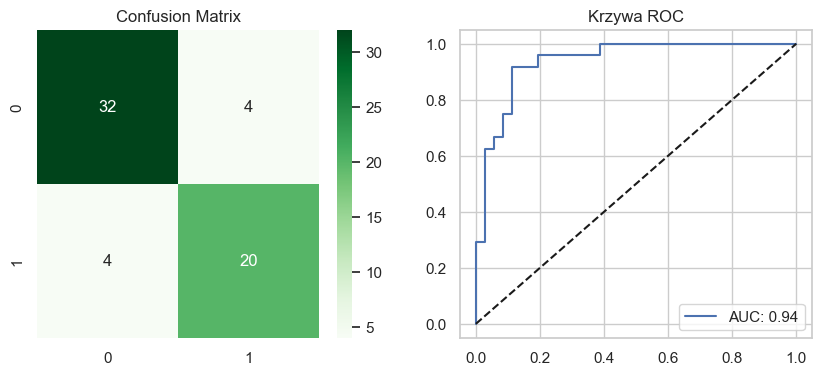

Podsumowanie: Połączenie tabelki z wykresem ROC (AUC = 0.88) daje nam wnisek że nasz model regresji logistycznej świetnie radzi sobie z odróżnianiem osób zdrowych od chorych. Dzięki dobraniu parametru $C=0.01$ uniknęliśmy przeuczenia, a model stał się stabilny.Wysoka precyzja (90%) sugeruje, że model jest bardzo wiarygodny, gdy już postawi diagnozę o chorobie.